# Stage 6 — Keyword & Phrase Extraction

Extract the most informative terms and phrases (unigrams + bigrams) from the preprocessed reviews.
We use TF-IDF with `ngram_range=(1,2)` to surface meaningful two-word phrases like
"frame rate", "open world", "skill tree", etc.

**Outputs**
- Top global keywords
- Top keywords for positive reviews
- Top keywords for negative reviews
- Saved to `data/processed/top_keywords.json`

## 1. Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='darkgrid')

# Load preprocessed data (has clean_review + voted_up + votes_up)
df = pd.read_csv('../data/processed/preprocessed_reviews.csv')
print(f'Loaded {len(df):,} reviews')
df.head(3)

Loaded 282,547 reviews


,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,updated,steamid,num_games_owned,num_reviews,playtime_forever,playtime_last_two_weeks,playtime_at_review,last_played,review_length,clean_review
0,153486817,english,"It's very fun. I don't usually like open world games, but this one is very nice. Writing, plot, characters are all e...",1702441215,1702441215,True,0,0,0.0,0,...,2023-12-13,76561198019963558,0,8,2482.0,2482.0,2452,1.702444e+09,209,fun dont usually like open world games one nice writing plot characters engaging gameplay fluid openended reminds bi...
1,153486487,english,fun,1702440650,1702440650,True,0,0,0.0,0,...,2023-12-13,76561199103884291,0,9,6634.0,441.0,6622,1.702441e+09,3,fun
2,153486273,english,Fun game,1702440259,1702440259,True,0,0,0.0,0,...,2023-12-13,76561198131623718,354,3,10328.0,3.0,10324,1.702440e+09,8,fun game


## 2. TF-IDF with Bigrams (Global)

In [2]:
# Build TF-IDF with unigrams + bigrams on the full corpus
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.85,
    sublinear_tf=True
)

# Drop rows with empty clean_review
df = df[df['clean_review'].notna() & (df['clean_review'].str.strip() != '')].copy()
df.reset_index(drop=True, inplace=True)

X = vectorizer.fit_transform(df['clean_review'].astype(str))
feature_names = vectorizer.get_feature_names_out()

print(f'TF-IDF matrix shape: {X.shape}')
print(f'Feature names sample: {feature_names[:10]}')

TF-IDF matrix shape: (282547, 15000)
Feature names sample: ['aaa' 'aaa game' 'aaa games' 'aaa title' 'aaa titles' 'abandon'
 'abandoned' 'abilities' 'ability' 'ability change']


## 3. Top Global Keywords

In [3]:
# Mean TF-IDF score across all reviews
mean_scores = np.asarray(X.mean(axis=0)).flatten()
top_idx = mean_scores.argsort()[::-1][:50]

top_global = pd.DataFrame({
    'keyword': feature_names[top_idx],
    'tfidf_score': mean_scores[top_idx]
})

print('Top 30 Global Keywords:')
print(top_global.head(30).to_string(index=False))

Top 30 Global Keywords:
   keyword  tfidf_score
      game     0.052104
      good     0.042750
       fun     0.022109
     great     0.021596
      bugs     0.019801
     story     0.017661
      like     0.015935
 good game     0.013801
   amazing     0.013478
       yes     0.013422
     still     0.012926
      play     0.012217
      love     0.012048
great game     0.011919
    really     0.011477
      time     0.010192
      best     0.010100
       get     0.009840
       one     0.009397
     buggy     0.009394
     world     0.009084
    better     0.009064
      even     0.008973
      nice     0.008971
 cyberpunk     0.008871
     worth     0.008825
      dont     0.008518
     games     0.008351
     would     0.008258
      much     0.008256


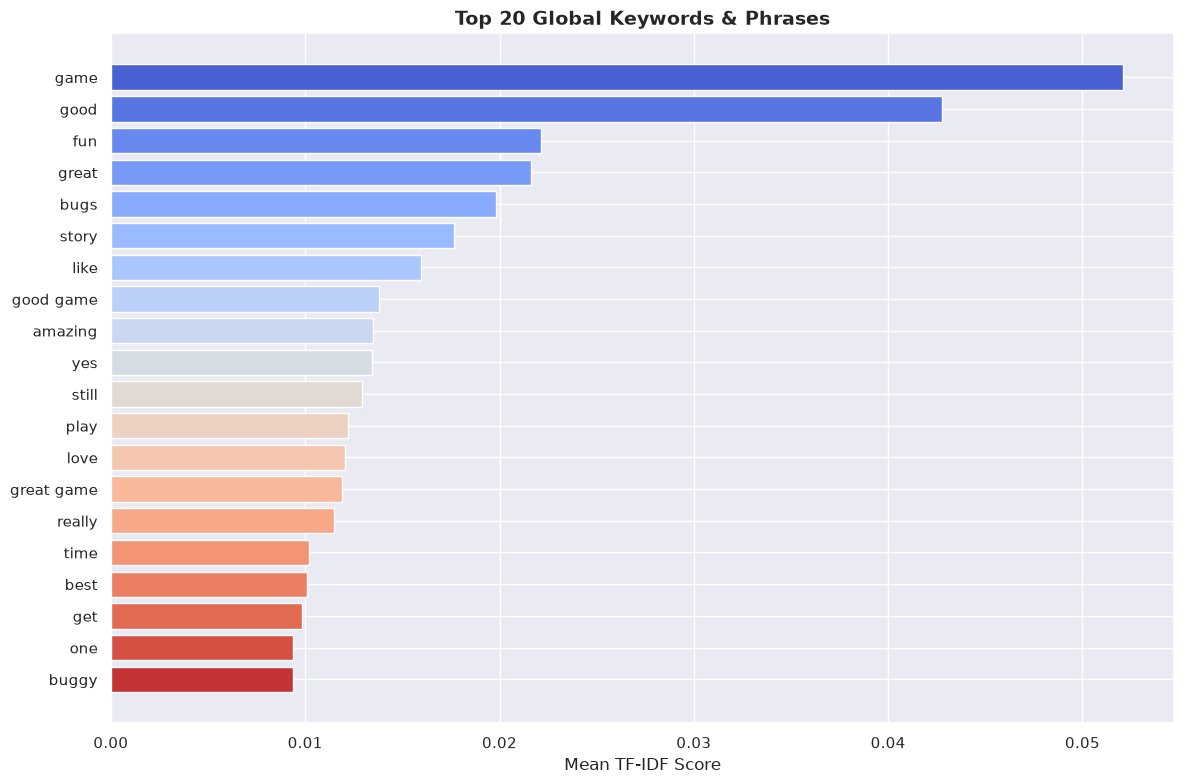

Saved chart.


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
top20 = top_global.head(20)
colors = sns.color_palette('coolwarm', 20)
bars = ax.barh(top20['keyword'][::-1], top20['tfidf_score'][::-1], color=colors[::-1])
ax.set_xlabel('Mean TF-IDF Score', fontsize=12)
ax.set_title('Top 20 Global Keywords & Phrases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/top_global_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart.')

## 4. Keywords by Sentiment Group

In [5]:
# Split by voted_up
pos_mask = df['voted_up'] == True
neg_mask = df['voted_up'] == False

print(f'Positive reviews: {pos_mask.sum():,}')
print(f'Negative reviews: {neg_mask.sum():,}')

def top_keywords_for_subset(mask, vectorizer, n=40):
    X_sub = vectorizer.transform(df.loc[mask, 'clean_review'].astype(str))
    mean_scores = np.asarray(X_sub.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:n]
    return pd.DataFrame({
        'keyword': feature_names[top_idx],
        'tfidf_score': mean_scores[top_idx]
    })

top_pos = top_keywords_for_subset(pos_mask, vectorizer)
top_neg = top_keywords_for_subset(neg_mask, vectorizer)

print('\nTop 20 Positive Keywords:')
print(top_pos.head(20).to_string(index=False))
print('\nTop 20 Negative Keywords:')
print(top_neg.head(20).to_string(index=False))

Positive reviews: 237,409
Negative reviews: 45,138



Top 20 Positive Keywords:
   keyword  tfidf_score
      game     0.052793
      good     0.048446
       fun     0.024918
     great     0.024511
      bugs     0.019857
     story     0.018415
 good game     0.015880
       yes     0.015601
   amazing     0.015548
      like     0.015227
great game     0.013863
      love     0.013709
     still     0.011994
      play     0.011914
    really     0.011523
      best     0.011257
      nice     0.010149
      time     0.009750
       one     0.009421
    better     0.009215

Top 20 Negative Keywords:
keyword  tfidf_score
   game     0.048484
   like     0.019658
   bugs     0.019508
   even     0.018335
  still     0.017825
    bad     0.016805
   dont     0.016024
   cant     0.014447
    get     0.014320
  buggy     0.014189
   play     0.013814
  story     0.013694
   good     0.012788
   time     0.012513
    buy     0.011310
   many     0.011272
 really     0.011235
  would     0.010917
   shit     0.010804
 boring     0.010758


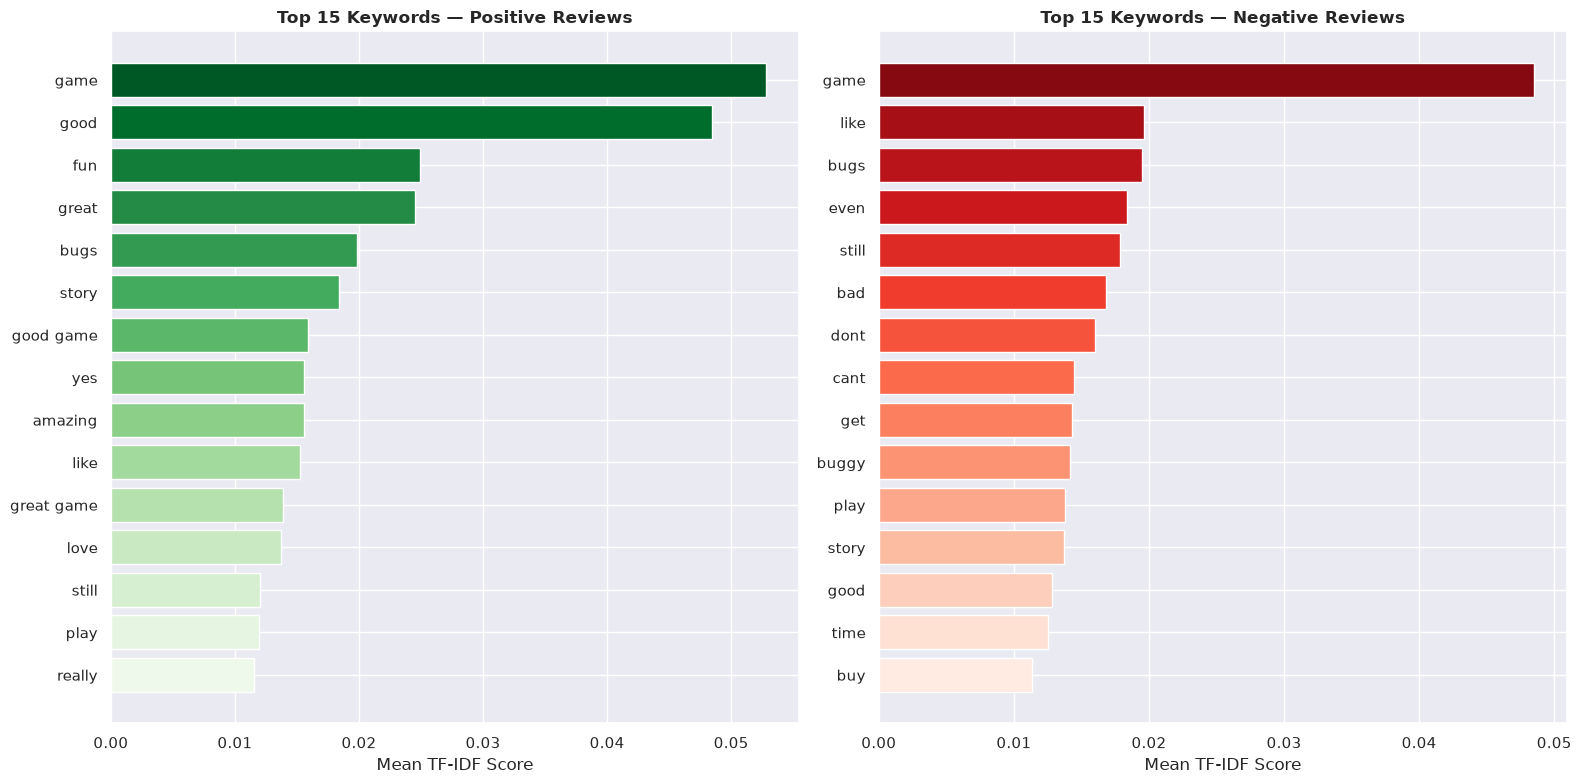

Saved chart.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, df_kw, title, palette in [
    (axes[0], top_pos.head(15), 'Top 15 Keywords — Positive Reviews', 'Greens_r'),
    (axes[1], top_neg.head(15), 'Top 15 Keywords — Negative Reviews', 'Reds_r'),
]:
    colors = sns.color_palette(palette, 15)
    ax.barh(df_kw['keyword'][::-1], df_kw['tfidf_score'][::-1], color=colors[::-1])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.savefig('../data/processed/keywords_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart.')

## 5. Save Results

In [7]:
output = {
    'global': top_global.head(50).to_dict(orient='records'),
    'positive': top_pos.head(50).to_dict(orient='records'),
    'negative': top_neg.head(50).to_dict(orient='records'),
}

with open('../data/processed/top_keywords.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Saved top_keywords.json')
print(f"Global keywords: {len(output['global'])}")
print(f"Positive keywords: {len(output['positive'])}")
print(f"Negative keywords: {len(output['negative'])}")

Saved top_keywords.json
Global keywords: 50
Positive keywords: 40
Negative keywords: 40
